In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df_index = pd.read_csv('economic_index.csv')

In [3]:
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [4]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               24 non-null     int64  
 1   month              24 non-null     int64  
 2   interest_rate      24 non-null     float64
 3   unemployment_rate  24 non-null     float64
 4   index_price        24 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 KB


In [5]:
# Drop Unnecessary Columns

df_index.drop(['year', 'month'], axis=1, inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


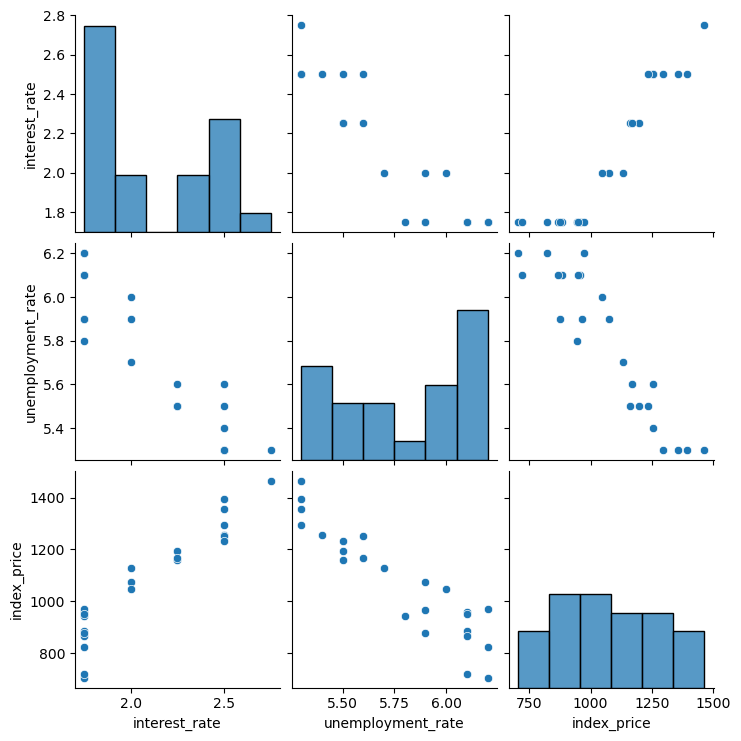

In [7]:
sns.pairplot(df_index)

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


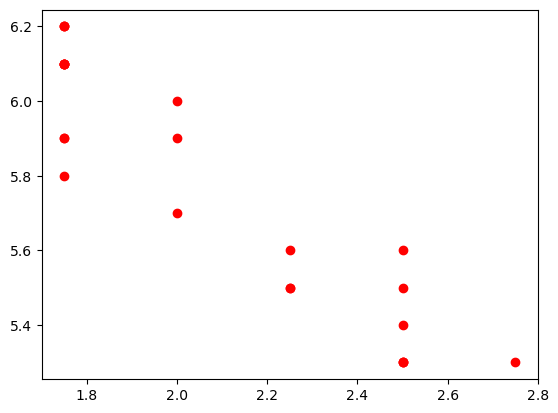

In [9]:
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color = 'r')

In [10]:
#Independent and dependent variable

X = df_index.iloc[:, :-1]
y = df_index.iloc[:, -1]

In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [13]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

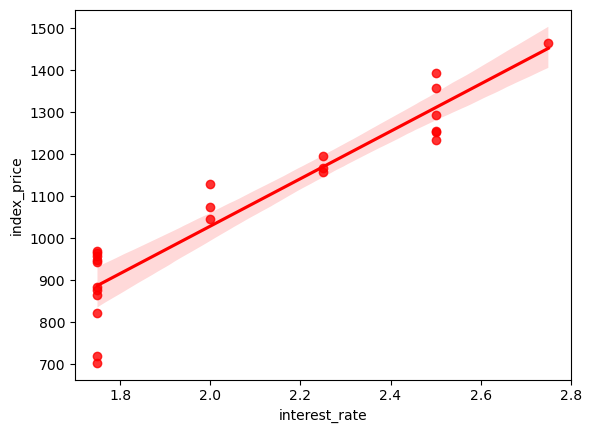

In [23]:
sns.regplot(
    data=df_index,
    x='interest_rate',
    y='index_price',
    color = 'r'
)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

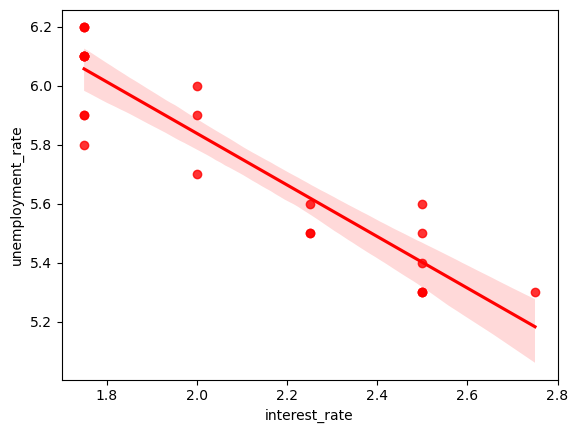

In [24]:
sns.regplot(
    data=df_index,
    x='interest_rate',
    y='unemployment_rate',
    color = 'r'
)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

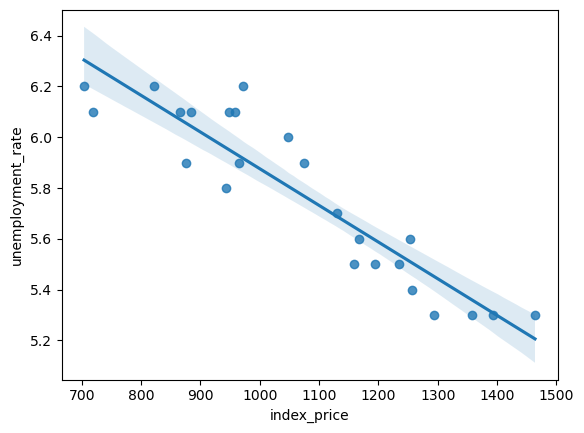

In [25]:
sns.regplot(
    x = df_index['index_price'],
    y = df_index['unemployment_rate'],
)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [30]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
regression = LinearRegression()

In [33]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
from sklearn.model_selection import cross_val_score

In [37]:
validation_score = cross_val_score(regression, X_train, y_train, scoring= 'neg_mean_squared_error', cv = 3)

In [40]:
import numpy as np
np.mean(validation_score)


np.float64(-5914.82818016239)

In [41]:
y_pred = regression.predict(X_test)

In [42]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [44]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [45]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rsme = np.sqrt(mse)
print('MAE: ', mae)
print('MSE: ', mse)
print('RSME: ', rsme)

MAE:  73.80444932337099
MSE:  8108.567426306611
RSME:  90.04758423359624


In [46]:
score = r2_score(y_test, y_pred)
print('R2 Score: ', score)

R2 Score:  0.7591371539010254


In [47]:
# Adjusted R2 Score
adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print('Adjusted R2 Score: ', adjusted_r2)

Adjusted R2 Score:  0.5985619231683756


In [48]:
import statsmodels.api as sm

model = sm.OLS(y_train , X_train).fit()

In [49]:
prediction = model.predict(X_test)

In [51]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 11 Jun 2026   Prob (F-statistic):                       0.754
Time:                        22:18:47   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

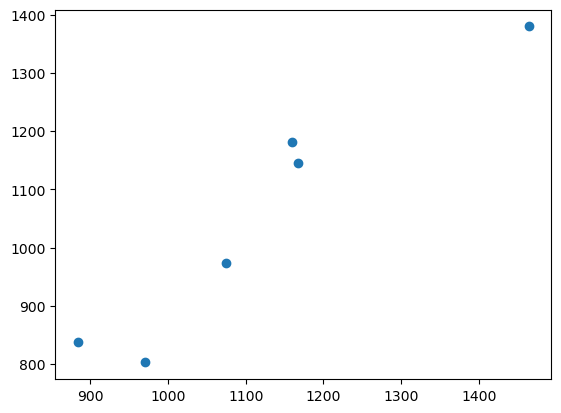

In [52]:
plt.scatter(y_test, y_pred)

In [53]:
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


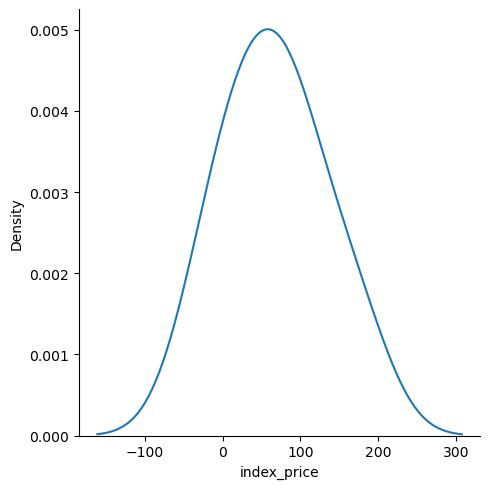

In [55]:
sns.displot(residuals, kind='kde')

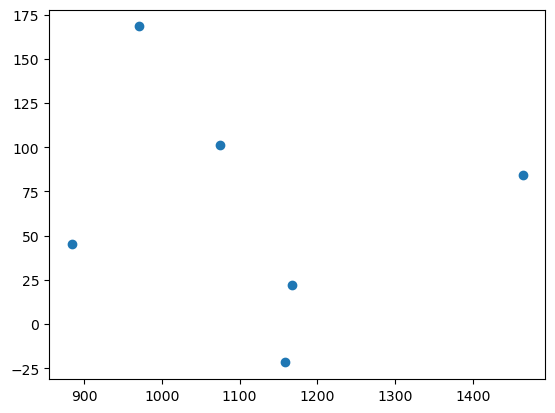

In [56]:
plt.scatter(y_test, residuals)

In [57]:
print(regression.coef_)

[  88.27275507 -116.25716066]
